### Lecture 3: Joint capacity and dispatch optimisation

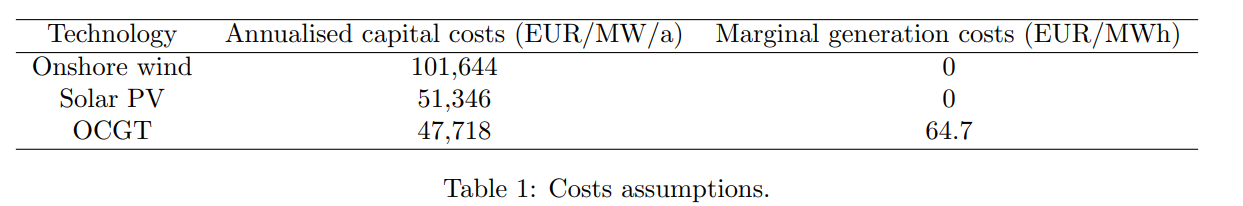

In [ ]:
# Packages
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

a) Calculate the total system cost, the optimal installed capacities, the annual generation per technology,
and plot the hourly generation and demand during January.

Aligned hours: 8760, from 2015-01-01 00:00:00+00:00 to 2015-12-31 23:00:00+00:00
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i7-10510U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 35040 rows, 26283 columns and 74478 nonzeros (Min)
Model fingerprint: 0x154eb312
Model has 8763 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-03, 1e+00]
  Objective range  [6e+01, 1e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+03, 9e+03]

Presolve removed 8724 rows and 8724 columns
Presolve time: 0.17s
Presolved: 26316 rows, 17559 columns, 57030 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.01s

Barrier statistics:
 Dense cols : 3
 AA' NZ     : 3.947e+04
 Factor NZ  : 1.273e+05 (roughly 20 MB of memory)
 Factor Ops : 6.632e+05 (less than

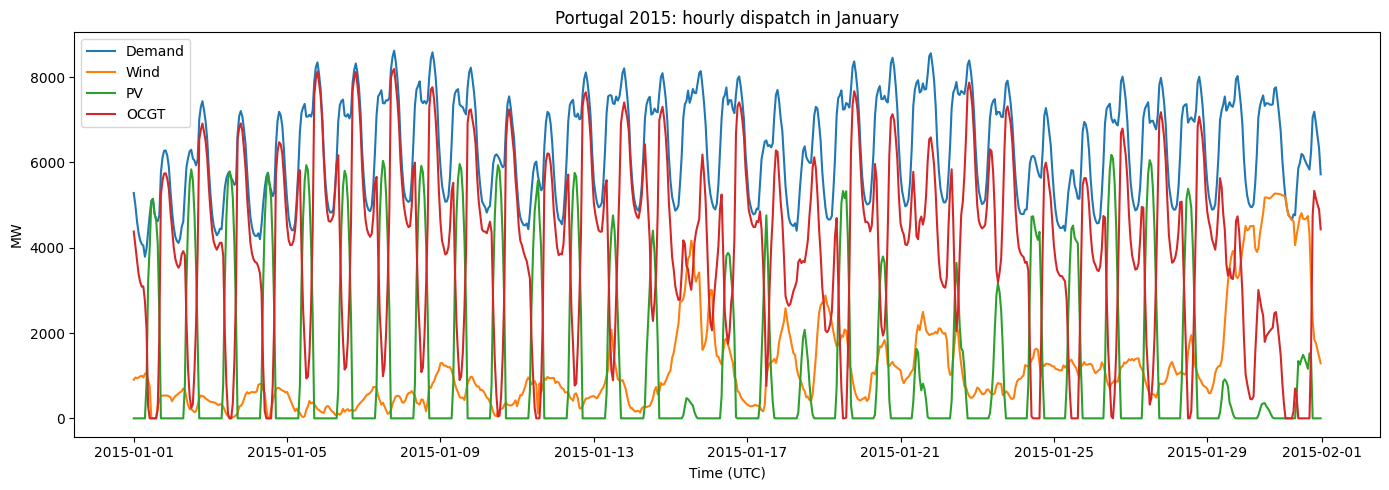

In [ ]:


# -----------------------
# Cost assumptions (EUR)
# -----------------------
C_w = 101644      # EUR/MW/a (wind capex annualised)
C_PV = 51346      # EUR/MW/a (PV capex annualised)
C_OCGT = 47718    # EUR/MW/a (OCGT capex annualised)

C_w_marginal = 0.0
C_PV_marginal = 0.0
C_OCGT_marginal = 64.7   # EUR/MWh (electricity) 

eta_OCGT = 0.41  # only needed if your marginal cost were per MWh_fuel (not the case here)

# -----------------------
# Load data
# -----------------------
path_wind = "onshore_wind.csv"
path_pv = "pv_optimal.csv"
path_demand = "electricity_demand.csv"

# Demand
demand_df = pd.read_csv(path_demand, sep=";")
demand_df["utc_time"] = pd.to_datetime(demand_df["utc_time"], utc=True)
demand = demand_df.set_index("utc_time")["PRT"].astype(float).sort_index()

# Wind
wind_df = pd.read_csv(path_wind, sep=";")
wind_df["utc_time"] = pd.to_datetime(wind_df["utc_time"], utc=True)
wind = wind_df.set_index("utc_time")["PRT"].astype(float).sort_index()

# PV
pv_df = pd.read_csv(path_pv, sep=";")
pv_df["utc_time"] = pd.to_datetime(pv_df["utc_time"], utc=True)
pv = pv_df.set_index("utc_time")["PRT"].astype(float).sort_index()

# -----------------------
# Filter to 2015 and align
# -----------------------
t0, t1 = "2015-01-01 00:00:00", "2015-12-31 23:00:00"

demand_2015 = demand.loc[t0:t1]
wind_2015   = wind.loc[t0:t1]
pv_2015     = pv.loc[t0:t1]

# Align to common index (very important)
idx = demand_2015.index.intersection(wind_2015.index).intersection(pv_2015.index)
demand_2015 = demand_2015.loc[idx]
wind_2015   = wind_2015.loc[idx]
pv_2015     = pv_2015.loc[idx]

# Optional sanity checks
assert len(idx) > 0, "No overlapping timestamps after filtering/alignment."
assert (wind_2015.between(0, 1) | wind_2015.isna()).all(), "Wind CF outside [0,1]?"
assert (pv_2015.between(0, 1) | pv_2015.isna()).all(), "PV CF outside [0,1]?"
wind_2015 = wind_2015.fillna(0.0)
pv_2015   = pv_2015.fillna(0.0)

T = len(idx)
demand_vals = demand_2015.to_numpy()
wind_cf = wind_2015.to_numpy()
pv_cf = pv_2015.to_numpy()

print(f"Aligned hours: {T}, from {idx.min()} to {idx.max()}")

# -----------------------
# Gurobi model
# -----------------------
m = gp.Model("IEG_L3_P3_1a_PRT_2015")

# Capacity variables (MW)
K_wind  = m.addVar(lb=0, name="K_wind")
K_pv    = m.addVar(lb=0, name="K_pv")
K_ocgt  = m.addVar(lb=0, name="K_ocgt")

# Dispatch variables (MW) for each hour
g_wind  = m.addVars(T, lb=0, name="g_wind")
g_pv    = m.addVars(T, lb=0, name="g_pv")
g_ocgt  = m.addVars(T, lb=0, name="g_ocgt")

balance = []

# Constraints
for t in range(T):
    # Power balance (inelastic demand)
    c = m.addConstr(g_wind[t] + g_pv[t] + g_ocgt[t] == demand_vals[t], name=f"balance_{t}")
    balance.append(c)

    # Renewable availability
    m.addConstr(g_wind[t] <= K_wind * wind_cf[t], name=f"wind_avail_{t}")
    m.addConstr(g_pv[t]   <= K_pv   * pv_cf[t],   name=f"pv_avail_{t}")

    # OCGT capacity
    m.addConstr(g_ocgt[t] <= K_ocgt, name=f"ocgt_cap_{t}")

# Objective: annualised capex + variable cost
capex_cost = C_w*K_wind + C_PV*K_pv + C_OCGT*K_ocgt
var_cost   = gp.quicksum(C_OCGT_marginal * g_ocgt[t] for t in range(T))

m.setObjective(capex_cost + var_cost, GRB.MINIMIZE)

# Solve
m.optimize()

if m.Status != GRB.OPTIMAL:
    raise RuntimeError(f"Not optimal. Status={m.Status}")

# -----------------------
# Results
# -----------------------
K_w = K_wind.X
K_s = K_pv.X
K_g = K_ocgt.X

gen_wind  = np.array([g_wind[t].X for t in range(T)])
gen_pv    = np.array([g_pv[t].X   for t in range(T)])
gen_ocgt  = np.array([g_ocgt[t].X for t in range(T)])

total_cost = m.ObjVal

annual_gen_MWh = {
    "wind":  gen_wind.sum(),
    "pv":    gen_pv.sum(),
    "ocgt":  gen_ocgt.sum()
}

print("\n=== Optimal installed capacities (MW) ===")
print(f"Wind  : {K_w:,.2f}")
print(f"PV    : {K_s:,.2f}")
print(f"OCGT  : {K_g:,.2f}")

print("\n=== Annual generation (MWh) ===")
for k,v in annual_gen_MWh.items():
    print(f"{k:5s}: {v:,.0f}")

print("\n=== Total system cost (EUR/a) ===")
print(f"{total_cost:,.0f}")

# Also useful: cost breakdown
capex_val = C_w*K_w + C_PV*K_s + C_OCGT*K_g
fuel_val  = C_OCGT_marginal * annual_gen_MWh["ocgt"]
print("\n=== Cost breakdown (EUR/a) ===")
print(f"Capex : {capex_val:,.0f}")
print(f"OCGT var: {fuel_val:,.0f}")

# -----------------------
# January plot (hourly generation + demand)
# -----------------------
jan_mask = (idx.month == 1)
idx_jan = idx[jan_mask]

plt.figure(figsize=(14,5))
plt.plot(idx_jan, demand_2015.loc[idx_jan].to_numpy(), label="Demand")
plt.plot(idx_jan, gen_wind[jan_mask], label="Wind")
plt.plot(idx_jan, gen_pv[jan_mask], label="PV")
plt.plot(idx_jan, gen_ocgt[jan_mask], label="OCGT")
plt.title("Portugal 2015: hourly dispatch in January")
plt.xlabel("Time (UTC)")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.show()


b) Calculate the revenues collected by every technology throughout the year and show that their sum is
equal to their costs.

In [12]:
# -----------------------
# 3.1(b) Revenues & costs
# -----------------------

# Hourly market price from duals of the balance constraints (EUR/MWh)
price = np.array([balance[t].Pi for t in range(T)])

# Revenues (EUR)
rev_wind  = float(np.dot(price, gen_wind))
rev_pv    = float(np.dot(price, gen_pv))
rev_ocgt  = float(np.dot(price, gen_ocgt))

# Costs (EUR)
cost_wind = C_w * K_w
cost_pv   = C_PV * K_s
cost_ocgt = C_OCGT * K_g + C_OCGT_marginal * annual_gen_MWh["ocgt"]

# Totals
total_rev = rev_wind + rev_pv + rev_ocgt
total_cost_check = cost_wind + cost_pv + cost_ocgt

# Demand payments (should match totals too)
demand_payment = float(np.dot(price, demand_vals))

print("\n=== Revenues (EUR/a) ===")
print(f"Wind : {rev_wind:,.0f}")
print(f"PV   : {rev_pv:,.0f}")
print(f"OCGT : {rev_ocgt:,.0f}")
print(f"TOTAL: {total_rev:,.0f}")

print("\n=== Costs (EUR/a) ===")
print(f"Wind : {cost_wind:,.0f}")
print(f"PV   : {cost_pv:,.0f}")
print(f"OCGT : {cost_ocgt:,.0f}")
print(f"TOTAL: {total_cost_check:,.0f}")

print("\n=== Checks ===")
print(f"Sum of tech revenues - sum of tech costs: {total_rev - total_cost_check:,.6f}")
print(f"Demand payments - total system cost (objective): {demand_payment - m.ObjVal:,.6f}")
print(f"Sum tech revenues - objective: {total_rev - m.ObjVal:,.6f}")

print("\n=== Per-technology profit (should be ~0) ===")
print(f"Wind profit : {rev_wind - cost_wind:,.6f}")
print(f"PV profit   : {rev_pv - cost_pv:,.6f}")
print(f"OCGT profit : {rev_ocgt - cost_ocgt:,.6f}")



=== Revenues (EUR/a) ===
Wind : 537,296,380
PV   : 426,318,332
OCGT : 2,135,205,625
TOTAL: 3,098,820,337

=== Costs (EUR/a) ===
Wind : 537,296,380
PV   : 426,318,332
OCGT : 2,135,205,625
TOTAL: 3,098,820,337

=== Checks ===
Sum of tech revenues - sum of tech costs: 0.000000
Demand payments - total system cost (objective): -0.000006
Sum tech revenues - objective: -0.000006

=== Per-technology profit (should be ~0) ===
Wind profit : -0.000000
PV profit   : -0.000000
OCGT profit : 0.000000


## Introducting BATTERY STORAGE

c) Calculate the total system cost, the optimal installed capacities, the annual generation per technology,
and plot the hourly generation and demand during January.

In [ ]:
C_battery = 12894  # EUR/MW/a
C_inverter = 24678 # EUR/MW/a
eta_inverter = 0.96
e2p_battery = 2 # hour, energy-to-power ratio of the battery (how many hours of discharge at full power)
K_CCGT = 6 # GW
eta_CCGT = 0.58
C_CCGT = 104788 # EUR/MW/a
C_CCGT_marginal = 46.8 # EUR/MWh

# -----------------------
# Gurobi model
# -----------------------
m = gp.Model("IEG_L3_P3_1c_PRT_2015")

# Capacity variables (MW)
K_wind  = m.addVar(lb=0, name="K_wind")
K_pv    = m.addVar(lb=0, name="K_pv")
K_ocgt  = m.addVar(lb=0, name="K_ocgt")
K_battery = m.addVar(lb=0, name="K_battery")
K_inverter = m.addVar(lb=0, name="K_inverter")

# Dispatch variables (MW) for each hour
g_wind  = m.addVars(T, lb=0, name="g_wind")
g_pv    = m.addVars(T, lb=0, name="g_pv")
g_ocgt  = m.addVars(T, lb=0, name="g_ocgt")
g_charge = m.addVars(T, lb=0, name="g_charge")  # battery charging (MW)
g_discharge = m.addVars(T, lb=0, name="g_discharge")  # battery discharging (MW)
g_CCGT = m.addVars(T, lb=0, name="g_CCGT")

balance = []

# Constraints
for t in range(T):
    # Power balance (inelastic demand)
    c2 = m.addConstr(g_wind[t] + g_pv[t] + g_ocgt[t] + g_CCGT[t] + g_charge[t] - g_discharge[t] == demand_vals[t], name=f"balance_{t}")
    balance.append(c2)

    # Renewable availability
    m.addConstr(g_wind[t] <= K_wind * wind_cf[t], name=f"wind_avail_{t}")
    m.addConstr(g_pv[t]   <= K_pv   * pv_cf[t],   name=f"pv_avail_{t}")

    # OCGT capacity
    m.addConstr(g_ocgt[t] <= K_ocgt, name=f"ocgt_cap_{t}")

    # Battery constraints
    m.addConstr(g_charge[t] <= K_battery * eta_inverter, name=f"charge_cap_{t}")
    m.addConstr(g_discharge[t] <= K_battery, name=f"discharge_cap_{t}")
    m.addConstr(g_charge[t] <= K_inverter, name=f"charge_inverter_{t}")
    m.addConstr(g_discharge[t] <= K_inverter, name=f"discharge_inverter_{t}")
    m.addConstr(g_discharge[t] <= e2p_battery * g_charge[t], name=f"battery_energy_{t}")
    
    # CCGT constraints
    m.addConstr(g_CCGT[t] <= K_CCGT, name=f"CCGT_cap_{t}")


# Objective: annualised capex + variable cost
capex_cost = C_w*K_wind + C_PV*K_pv + C_OCGT*K_ocgt + C_battery*K_battery + C_inverter*K_inverter
var_cost   = gp.quicksum(C_OCGT_marginal * g_ocgt[t] + C_CCGT_marginal * g_CCGT[t] for t in range(T))

m.setObjective(capex_cost + var_cost, GRB.MINIMIZE)

# Solve
m.optimize()

if m.Status != GRB.OPTIMAL:
    raise RuntimeError(f"Not optimal. Status={m.Status}")

In [ ]:
# -----------------------
# Results
# -----------------------
K_w = K_wind.X
K_s = K_pv.X
K_g = K_ocgt.X
K_b = K_battery.X
K_i = K_inverter.X

gen_wind  = np.array([g_wind[t].X for t in range(T)])
gen_pv    = np.array([g_pv[t].X   for t in range(T)])
gen_ocgt  = np.array([g_ocgt[t].X for t in range(T)])
gen_ccgt  = np.array([g_CCGT[t].X for t in range(T)])

total_cost = m.ObjVal

annual_gen_MWh = {
    "wind":  gen_wind.sum(),
    "pv":    gen_pv.sum(),
    "ocgt":  gen_ocgt.sum(),
    "ccgt":  gen_ccgt.sum()
}

print("\n=== Optimal installed capacities (MW) ===")
print(f"Wind  : {K_w:,.2f}")
print(f"PV    : {K_s:,.2f}")
print(f"OCGT  : {K_g:,.2f}")
print(f"Battery: {K_b:,.2f}")
print(f"Inverter: {K_i:,.2f}")
print("\n=== Annual generation (MWh) ===")
for k,v in annual_gen_MWh.items():
    print(f"{k:5s}: {v:,.0f}")

print("\n=== Total system cost (EUR/a) ===")
print(f"{total_cost:,.0f}")

# Also useful: cost breakdown
capex_val = C_w*K_w + C_PV*K_s + C_OCGT*K_g + C_battery*K_b + C_inverter*K_i + C_CCGT*K_CCGT
fuel_val  = C_OCGT_marginal * annual_gen_MWh["ocgt"] + C_CCGT_marginal * annual_gen_MWh["ccgt"]
print("\n=== Cost breakdown (EUR/a) ===")
print(f"Capex : {capex_val:,.0f}")
print(f"OCGT var: {fuel_val:,.0f}")

# -----------------------
# January plot (hourly generation + demand)
# -----------------------
jan_mask = (idx.month == 1)
idx_jan = idx[jan_mask]

plt.figure(figsize=(14,5))
plt.plot(idx_jan, demand_2015.loc[idx_jan].to_numpy(), label="Demand")
plt.plot(idx_jan, gen_wind[jan_mask], label="Wind")
plt.plot(idx_jan, gen_pv[jan_mask], label="PV")
plt.plot(idx_jan, gen_ocgt[jan_mask], label="OCGT")
plt.title("Portugal 2015: hourly dispatch in January")
plt.xlabel("Time (UTC)")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.show()
